<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-07-25 18:31:30--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.2’

survey-data.csv.2   100%[===================>] 152.13M  47.2MB/s    in 3.2s    

2026-07-25 18:31:35 (47.2 MB/s) - ‘survey-data.csv.2’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [23]:
!pip install pandas 
!pip install matplotlib
!pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [5]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [17]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
#QUERY = "SELECT * FROM main LIMIT 5"
QUERY = "SELECT * FROM main"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
#print(df_check)
df_check.head(10)
df_check.shape
df_check.dtypes



ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [11]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [12]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [19]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [20]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])



,sql
0,"CREATE TABLE ""main"" (\n""ResponseId"" INTEGER,\n..."


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


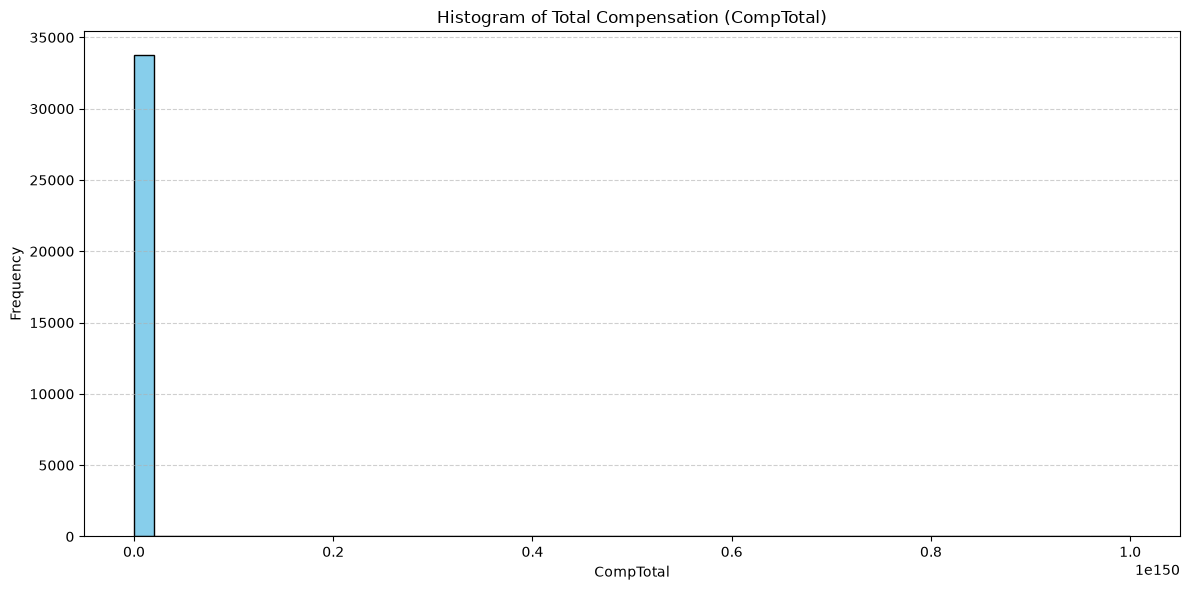

In [25]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure CompTotal is numeric
df_check['CompTotal'] = pd.to_numeric(df_check['CompTotal'], errors='coerce')

# Drop missing values
comp_total = df_check['CompTotal'].dropna()

# Plot histogram
import matplotlib.pyplot as plt
import pandas as pd



# Plot histogram (no KDE)
plt.figure(figsize=(12,6))
plt.hist(comp_total, bins=50, color='skyblue', edgecolor='black')

plt.title("Histogram of Total Compensation (CompTotal)")
plt.xlabel("CompTotal")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



**Box Plots**

Plot a box plot of Age.


/tmp/ipykernel_301/2432898828.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(age_values, vert=True, patch_artist=True,


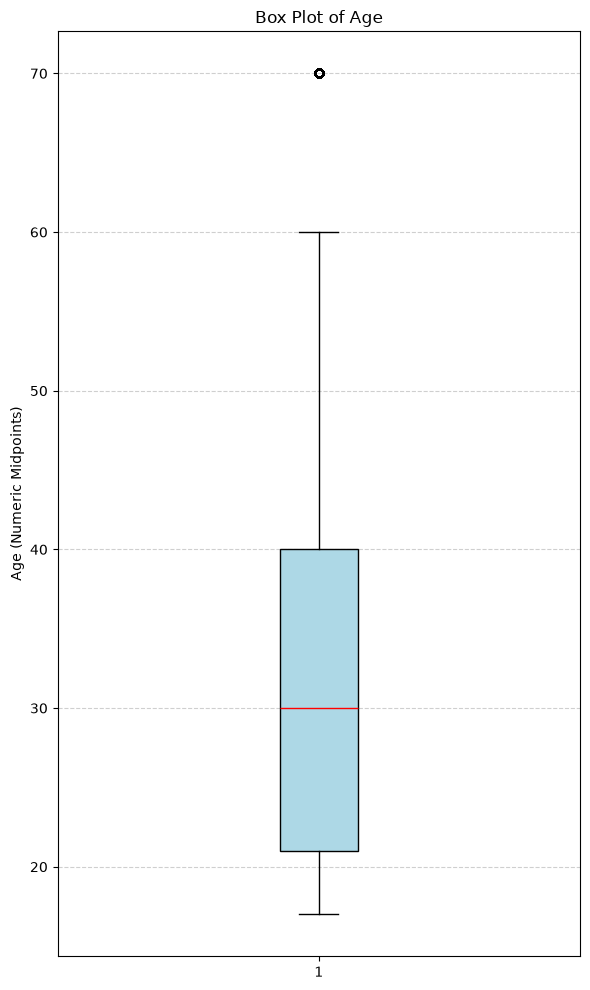

In [26]:
## Write your code here
#map age categories to numeric midpoints
def map_age(age):
    if pd.isna(age):
        return None
    age = str(age)

    if "Under 18" in age:
        return 17
    elif "18" in age and "24" in age:
        return 21
    elif "25" in age and "34" in age:
        return 30
    elif "35" in age and "44" in age:
        return 40
    elif "45" in age and "54" in age:
        return 50
    elif "55" in age and "64" in age:
        return 60
    elif "65" in age:
        return 70
    else:
        return None

df_check['Age_numeric'] = df_check['Age'].apply(map_age)
age_values = df_check['Age_numeric'].dropna()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,10))
plt.boxplot(age_values, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue'),
            medianprops=dict(color='red'))

plt.title("Box Plot of Age")
plt.ylabel("Age (Numeric Midpoints)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


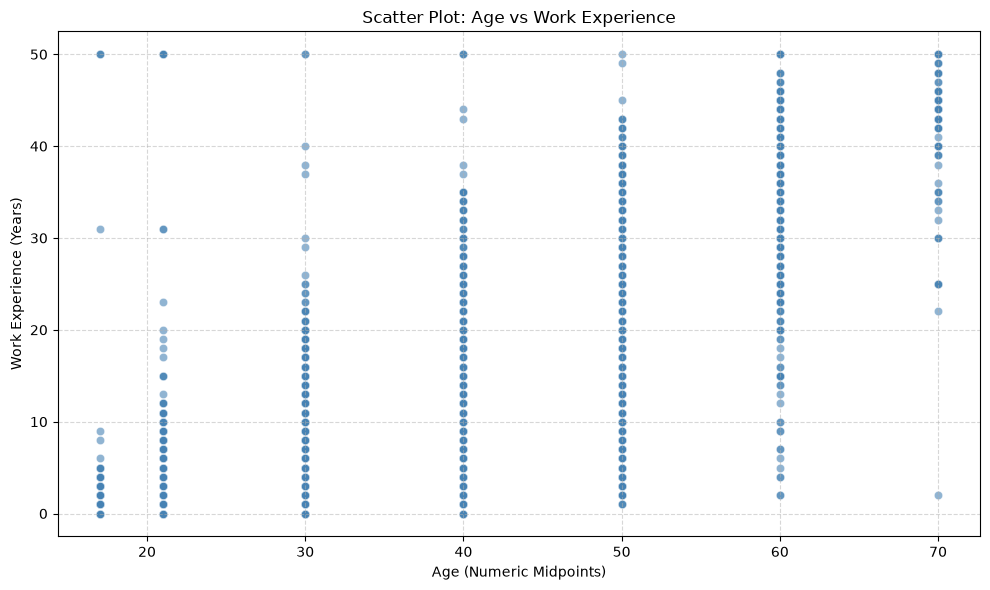

In [27]:
## Write your code here
#Convert Age → numeric midpoints
def map_age(age):
    if pd.isna(age):
        return None
    age = str(age)

    if "Under 18" in age:
        return 17
    elif "18" in age and "24" in age:
        return 21
    elif "25" in age and "34" in age:
        return 30
    elif "35" in age and "44" in age:
        return 40
    elif "45" in age and "54" in age:
        return 50
    elif "55" in age and "64" in age:
        return 60
    elif "65" in age:
        return 70
    else:
        return None

df_check['Age_numeric'] = df_check['Age'].apply(map_age)
df_check['WorkExp'] = pd.to_numeric(df_check['WorkExp'], errors='coerce')
#Scatter plot: Age vs WorkExp
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_check,
    x='Age_numeric',
    y='WorkExp',
    alpha=0.6,
    color='steelblue'
)

plt.title("Scatter Plot: Age vs Work Experience")
plt.xlabel("Age (Numeric Midpoints)")
plt.ylabel("Work Experience (Years)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


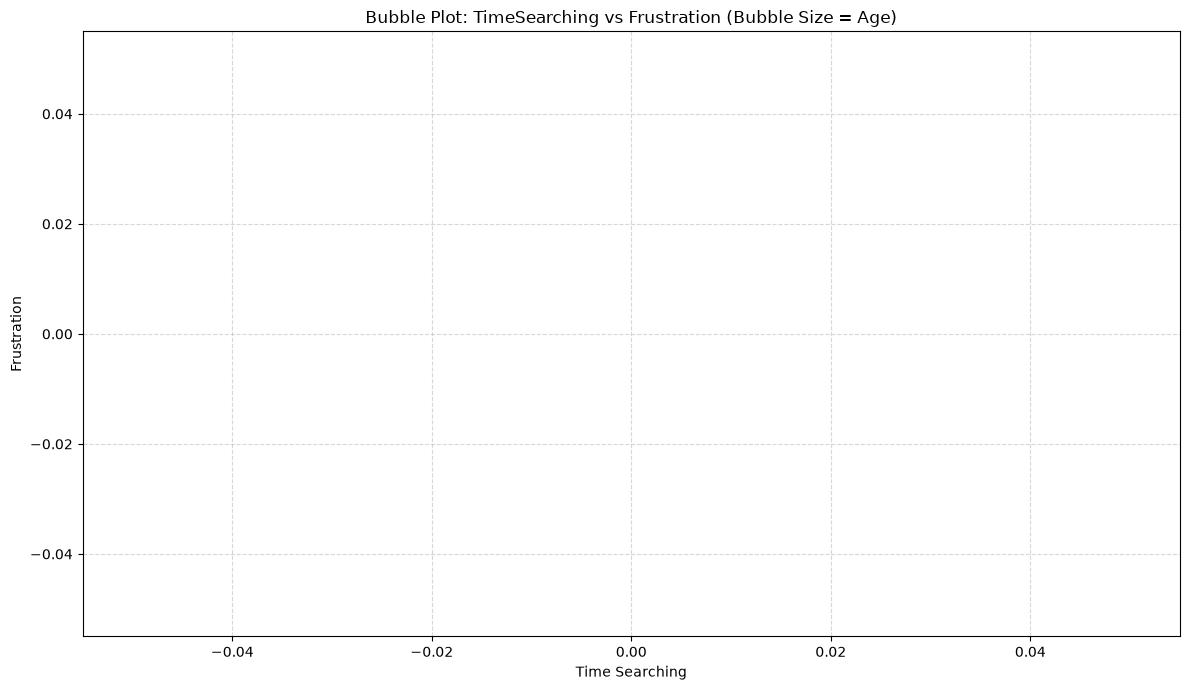

In [32]:
def map_age(age):
    if pd.isna(age):
        return None
    age = str(age)

    if "Under 18" in age:
        return 17
    elif "18" in age and "24" in age:
        return 21
    elif "25" in age and "34" in age:
        return 30
    elif "35" in age and "44" in age:
        return 40
    elif "45" in age and "54" in age:
        return 50
    elif "55" in age and "64" in age:
        return 60
    elif "65" in age:
        return 70
    else:
        return None

df_check['Age_numeric'] = df_check['Age'].apply(map_age)
df_check['TimeSearching'] = pd.to_numeric(df_check['TimeSearching'], errors='coerce')
df_check['Frustration'] = pd.to_numeric(df_check['Frustration'], errors='coerce')

import matplotlib.pyplot as plt
import seaborn as sns

# Drop rows with missing values
bubble_df = df_check[['TimeSearching', 'Frustration', 'Age_numeric']].dropna()

plt.figure(figsize=(12,7))

plt.scatter(
    bubble_df['TimeSearching'],
    bubble_df['Frustration'],
    s=bubble_df['Age_numeric'] * 5,   # scale bubble size
    alpha=0.5,
    c=bubble_df['Age_numeric'],
    cmap='viridis'
)

plt.title("Bubble Plot: TimeSearching vs Frustration (Bubble Size = Age)")
plt.xlabel("Time Searching")
plt.ylabel("Frustration")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()








### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


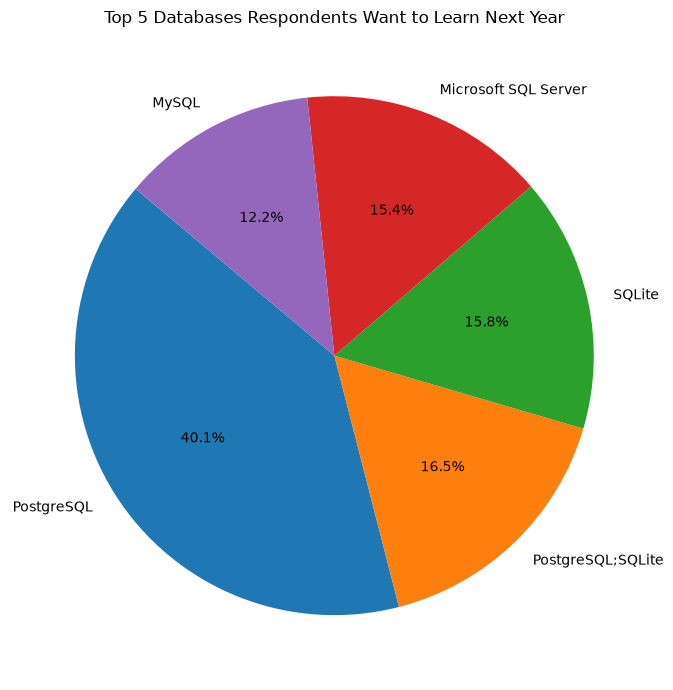

In [33]:
## Write your code here
import matplotlib.pyplot as plt

# Drop missing values
db_series = df_check['DatabaseWantToWorkWith'].dropna()

# Count frequencies
db_counts = db_series.value_counts().head(5)

# Plot pie chart
plt.figure(figsize=(10,7))
plt.pie(
    db_counts.values,
    labels=db_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Top 5 Databases Respondents Want to Learn Next Year")
plt.tight_layout()
plt.show()


**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


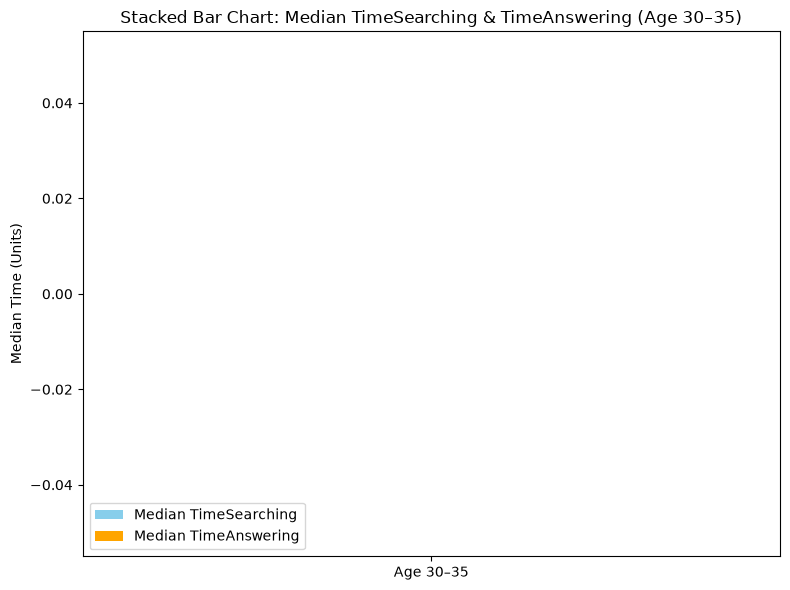

In [34]:
## Write your code here
def map_age(age):
    if pd.isna(age):
        return None
    age = str(age)

    if "Under 18" in age: return 17
    if "18-24" in age: return 21
    if "25-34" in age: return 30
    if "35-44" in age: return 40
    if "45-54" in age: return 50
    if "55-64" in age: return 60
    if "65" in age: return 70
    return None

df_check['Age_numeric'] = df_check['Age'].apply(map_age)
df_check['TimeSearching'] = pd.to_numeric(df_check['TimeSearching'], errors='coerce')
df_check['TimeAnswering'] = pd.to_numeric(df_check['TimeAnswering'], errors='coerce')
age_group = df_check[(df_check['Age_numeric'] >= 30) & (df_check['Age_numeric'] <= 35)]
median_searching = age_group['TimeSearching'].median()
median_answering = age_group['TimeAnswering'].median()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.bar(
    ['Age 30–35'],
    [median_searching],
    label='Median TimeSearching',
    color='skyblue'
)

plt.bar(
    ['Age 30–35'],
    [median_answering],
    bottom=[median_searching],
    label='Median TimeAnswering',
    color='orange'
)

plt.title("Stacked Bar Chart: Median TimeSearching & TimeAnswering (Age 30–35)")
plt.ylabel("Median Time (Units)")
plt.legend()
plt.tight_layout()
plt.show()


### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


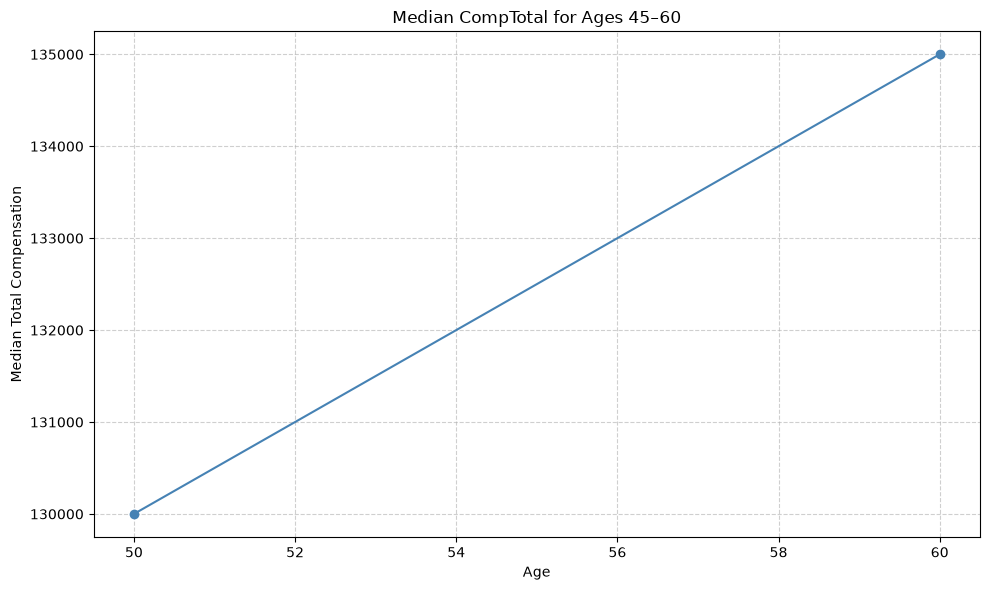

In [36]:
## Write your code here
def map_age(age):
    if pd.isna(age):
        return None
    age = str(age)

    if "Under 18" in age: return 17
    if "18-24" in age: return 21
    if "25-34" in age: return 30
    if "35-44" in age: return 40
    if "45-54" in age: return 50
    if "55-64" in age: return 60
    if "65" in age: return 70
    return None

df_check['CompTotal'] = pd.to_numeric(df_check['CompTotal'], errors='coerce')

age_group = df_check[(df_check['Age_numeric'] >= 45) & (df_check['Age_numeric'] <= 60)]

median_by_age = age_group.groupby('Age_numeric')['CompTotal'].median()
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(median_by_age.index, median_by_age.values, marker='o', linestyle='-', color='steelblue')

plt.title("Median CompTotal for Ages 45–60")
plt.xlabel("Age")
plt.ylabel("Median Total Compensation")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


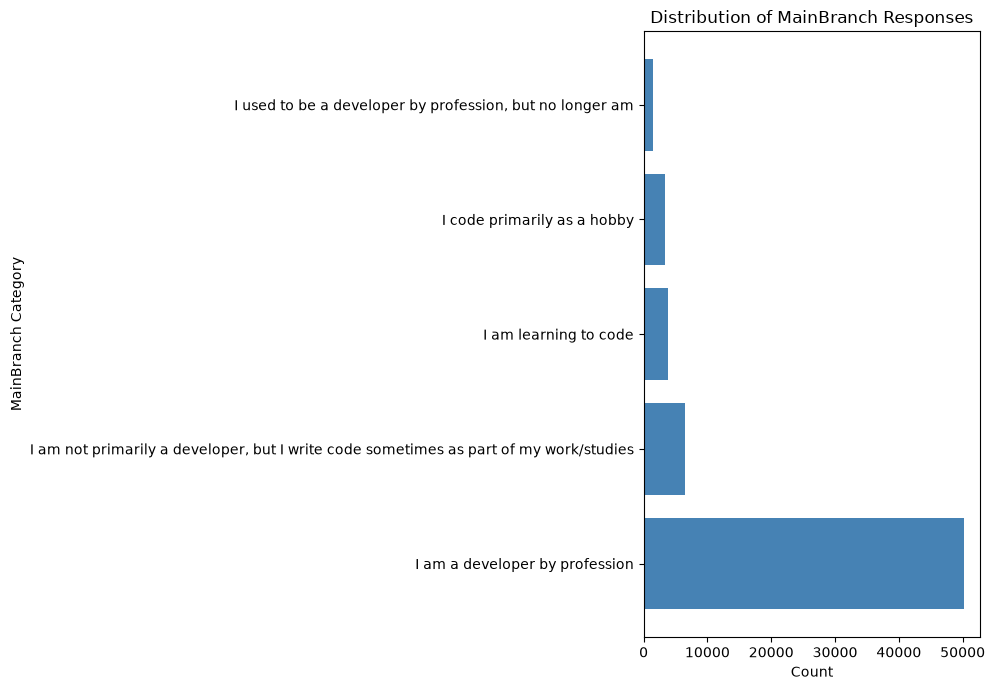

In [37]:
## Write your code here
main_counts = df_check['MainBranch'].value_counts()
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.barh(main_counts.index, main_counts.values, color='steelblue')

plt.title("Distribution of MainBranch Responses")
plt.xlabel("Count")
plt.ylabel("MainBranch Category")
plt.tight_layout()
plt.show()


### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [ ]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
